# 01 — Download & Organize NDWS 

In [1]:
import os
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"

In [ ]:
# --- Robust project root + config + autodiscovery ---
from pathlib import Path
import sys, yaml, re, zipfile

def find_root():
    here = Path.cwd()
    for p in [here, *here.parents]:
        if (p / "config.yaml").exists() and (p / "src").is_dir():
            return p
        if (p / "ignis_ml" / "config.yaml").exists() and (p / "ignis_ml" / "src").is_dir():
            return p / "ignis_ml"
    raise FileNotFoundError("Couldn't locate project root with config.yaml and src/")

ROOT = find_root()
print("Project root:", ROOT)

# ensure imports like 'from src.data...' work
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

CFG = yaml.safe_load((ROOT / "config.yaml").read_text())

def under_root(p: str) -> Path:
    P = Path(p)
    if P.is_absolute():
        return P
    
    if P.parts and P.parts[0] == ROOT.name:
        P = Path(*P.parts[1:])
    return (ROOT / P).resolve()

configured_raw = under_root(CFG["ndws"]["raw_dir"])  # e.g. ignis_ml/data/NDWS_raw
data_dir = ROOT / "data"

# Prefer the directory that actually exists
raw_candidates = [
    configured_raw,
    ROOT / "data/mNDWS_raw",
    ROOT / "data/NDWS_raw",
    data_dir,
]

RAW_BASE = next((p for p in raw_candidates if p.exists()), None)
if RAW_BASE is None:
    raise FileNotFoundError(f"No candidate raw dir found among: {raw_candidates}")

# Find a child like "*ndws*western*dataset*" (case-insensitive)
dataset_dir = None
pat = re.compile(r"ndws.*western.*dataset", re.I)
for child in RAW_BASE.rglob("*"):
    if child.is_dir() and pat.search(child.name):
        dataset_dir = child
        break

RAW = dataset_dir if dataset_dir else RAW_BASE  # fall back to base if files live directly there
PROC_ROOT = under_root(CFG["ndws"]["proc_dir"])      # e.g. ignis_ml/data/NDWS
OUT = PROC_ROOT.with_name("mNDWS_500m")

RAW.mkdir(parents=True, exist_ok=True)
OUT.mkdir(parents=True, exist_ok=True)

print("RAW_BASE:", RAW_BASE)
print("RAW (dataset folder):", RAW)
print("OUT:", OUT)

# --- Import ETL helpers now that sys.path is set ---
from src.data.etl_ndws import peek_keys, convert_mndws_to_tiles

# --- Auto-unzip any Kaggle zips dropped in RAW (or its base) ---
for z in list(RAW.glob("*.zip")) + list(RAW_BASE.glob("*.zip")):
    print("Unzipping:", z.name)
    with zipfile.ZipFile(z) as zf:
        zf.extractall(z.parent)

# --- Discover files (npz / tfrecord) under RAW ---
npz_files = sorted(RAW.rglob("*.npz"))
tfr_files = sorted(RAW.rglob("*.tfrecord*"))

print(f"Found {len(npz_files)} NPZ, {len(tfr_files)} TFRecord under {RAW}")
if not npz_files and not tfr_files:
    raise FileNotFoundError(
        f"No .npz/.tfrecord under {RAW}\n"
        f"• If files are somewhere else under {data_dir}, move them under {RAW_BASE}\n"
        f"• Folder names checked (case-insensitive): *ndws*western*dataset*\n"
        f"• Current config ndws.raw_dir: {CFG['ndws']['raw_dir']}"
    )

sample = (npz_files or tfr_files)[0]
print("Sample file:", sample)
peek_keys(sample)

# --- Convert to standardized tiles (train == serve schema) ---
convert_mndws_to_tiles(
    raw_dir=str(RAW),
    out_dir=str(OUT),
    res_m=int(CFG["grid"]["res_m"]),         # 500
    tile_km=int(CFG["grid"]["size"]),        # 64 or 128 depending on your config
    time_steps=int(CFG["train"]["time_steps"])
)

print("First tiles:", sorted(OUT.glob("*.npz"))[:3])

Project root: /Users/chrisjuarez/ignis_ml
RAW_BASE: /Users/chrisjuarez/ignis_ml/data/mNDWS_raw
RAW (dataset folder): /Users/chrisjuarez/ignis_ml/data/mNDWS_raw/ndws_western_dataset
OUT: /Users/chrisjuarez/ignis_ml/data/mNDWS_500m
Found 0 NPZ, 54 TFRecord under /Users/chrisjuarez/ignis_ml/data/mNDWS_raw/ndws_western_dataset
Sample file: /Users/chrisjuarez/ignis_ml/data/mNDWS_raw/ndws_western_dataset/cleaned_eval_ndws_conus_western_000.tfrecord
TFRecord keys: ['gust_med', 'wind_75', 'elevation', 'population', 'chili', 'impervious', 'fuel3', 'viirs_PrevFireMask', 'fuel2', 'viirs_FireMask', 'fuel1', 'pdsi', 'water', 'tmp_day', 'erc', 'NDVI', 'pr', 'wdir_wind', 'wdir_gust', 'bi', 'tmp_75', 'avg_sph', 'wind_avg']
Done. Wrote ~20097 tiles to /Users/chrisjuarez/ignis_ml/data/mNDWS_500m
First tiles: [PosixPath('/Users/chrisjuarez/ignis_ml/data/mNDWS_500m/mndws_cleaned_eval_ndws_conus_western_000_003770.npz'), PosixPath('/Users/chrisjuarez/ignis_ml/data/mNDWS_500m/mndws_cleaned_eval_ndws_conus_w

In [3]:
from pathlib import Path
import numpy as np

one = sorted(Path("/Users/chrisjuarez/ignis_ml/data/mNDWS_500m").glob("*.npz"))[0]
d = np.load(one)
print("x_dyn:", d["x_dyn"].shape, "x_stat:", d["x_stat"].shape, "y:", d["y"].shape)
print("dyn channels:", d["x_dyn"].shape[1], "stat channels:", d["x_stat"].shape[0])

x_dyn: (6, 8, 64, 64) x_stat: (15, 64, 64) y: (64, 64)
dyn channels: 8 stat channels: 15


In [4]:
# --- Locate project root and the mNDWS_500m tiles dir ---
from pathlib import Path
import numpy as np, pandas as pd, math, random

ROOT = Path.cwd()
for p in [ROOT, *ROOT.parents]:
    if (p / "config.yaml").exists() and (p / "src").is_dir():
        ROOT = p; break

OUT = ROOT / "data" / "mNDWS_500m"
files = sorted(OUT.glob("*.npz"))
print("ROOT:", ROOT)
print("#tiles:", len(files))
assert files, "No tiles found. Check OUT path."

ROOT: /Users/chrisjuarez/ignis_ml
#tiles: 20097


In [5]:
# Dynamic order we wrote in ETL
DYN_NAMES = ["fire_t","frp","u","v","temp","rh","prcp"]

# Statics: base 4 first, then any present in this order (trimmed to your Cs)
STAT_BASE = ["elev","slope","aspect_cos","aspect_sin"]
STAT_EXTRA = ["fuel1","fuel2","fuel3","NDVI","BI","ERC","PDSI","water","impervious","population","CHILI"]

def stat_names_for(tile_cs: int):
    names = STAT_BASE + STAT_EXTRA
    return names[:tile_cs]

x_dyn: (6, 8, 64, 64) x_stat: (15, 64, 64) y: (64, 64)
dyn names: ['fire_t', 'frp', 'u', 'v', 'temp', 'rh', 'prcp']
stat names: ['elev', 'slope', 'aspect_cos', 'aspect_sin', 'fuel1', 'fuel2', 'fuel3', 'NDVI', 'BI', 'ERC', 'PDSI', 'water', 'impervious', 'population', 'CHILI']


(-0.5, 63.5, 63.5, -0.5)

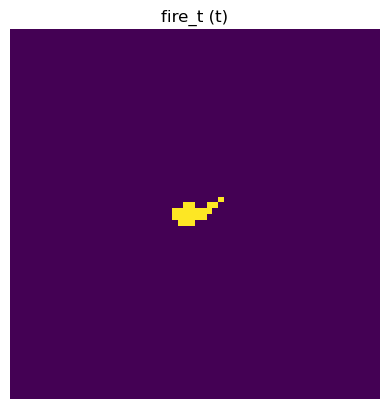

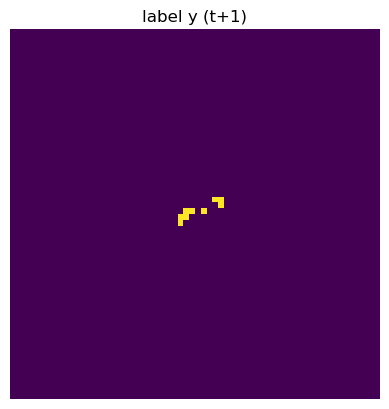

In [6]:
import matplotlib.pyplot as plt

sample = np.load(files[0])
x_dyn, x_stat, y = sample["x_dyn"], sample["x_stat"], sample["y"]
print("x_dyn:", x_dyn.shape, "x_stat:", x_stat.shape, "y:", y.shape)
print("dyn names:", DYN_NAMES)
print("stat names:", stat_names_for(x_stat.shape[0]))

# Quick side-by-side: fire_t (last step), label y
plt.figure(); plt.title("fire_t (t)")
plt.imshow(x_dyn[-1,0]); plt.axis("off")

plt.figure(); plt.title("label y (t+1)")
plt.imshow(y); plt.axis("off")

In [7]:
random.seed(7)
S = min(2000, len(files))           # sample size
subset = random.sample(files, S)

def pct01(a): 
    a = a.ravel()
    return np.percentile(a, 1), np.percentile(a, 99)

dyn_rows, stat_rows, label_rows = [], [], []

for p in subset:
    d = np.load(p)
    x0 = d["x_dyn"].astype("float32")   # [T,7,H,W]
    x1 = d["x_stat"].astype("float32")  # [Cs,H,W]
    yy = d["y"].astype("float32")       # [H,W]

    # Per-channel stats (aggregate over T,H,W for dyn; H,W for stat)
    T, C0, H, W = x0.shape
    C1 = x1.shape[0]
    # collapse T,H,W
    dyn_flat = x0.reshape(T*C0*H*W).reshape(T, C0, H, W).transpose(1,0,2,3).reshape(C0, -1)
    for ci, name in enumerate(DYN_NAMES):
        v = dyn_flat[ci]
        m, s = float(v.mean()), float(v.std())
        mn, mx = float(v.min()), float(v.max())
        p1, p99 = pct01(v)
        z = float((v==0).mean())
        dyn_rows.append((name, m, s, mn, mx, p1, p99, z))

    # stat
    for ci, name in enumerate(stat_names_for(C1)):
        v = x1[ci].ravel()
        m, s = float(v.mean()), float(v.std())
        mn, mx = float(v.min()), float(v.max())
        p1, p99 = pct01(v)
        z = float((v==0).mean())
        stat_rows.append((name, m, s, mn, mx, p1, p99, z))

    # labels
    fire_frac = float(yy.mean())  # % of pixels on fire at t+1
    label_rows.append((p.name, fire_frac))

df_dyn  = pd.DataFrame(dyn_rows, columns=["channel","mean","std","min","max","p1","p99","pct_zero"])
df_stat = pd.DataFrame(stat_rows, columns=["channel","mean","std","min","max","p1","p99","pct_zero"])
df_lab  = pd.DataFrame(label_rows, columns=["tile","y_fire_frac"])

print("Dynamic summary:\n", df_dyn.groupby("channel").agg(["mean","std"]).round(4))
print("\nStatic summary:\n", df_stat.groupby("channel").agg(["mean","std"]).round(4))
print("\nLabel fire fraction (sample):")
df_lab.describe(percentiles=[.5,.9,.99]).round(6)

Dynamic summary:
             mean             std              min              max          \
            mean     std    mean     std     mean     std     mean     std   
channel                                                                      
fire_t    0.0381  0.0451  0.1636  0.0884   0.0000  0.0000   1.0000  0.0000   
frp      -0.0246  0.0659  0.0418  0.0292  -0.1178  0.0702   0.0735  0.0982   
prcp      0.0054  0.0019  0.0004  0.0003   0.0047  0.0018   0.0064  0.0021   
rh       21.8374  6.7917  1.9127  0.9101  17.5962  6.7704  25.7919  7.0005   
temp      4.5152  2.2556  0.9073  0.6139   2.6928  1.4484   6.6348  3.2379   
u        -2.5686  1.2106  0.5830  0.3886  -3.9963  1.8865  -1.4326  0.8195   
v         2.5697  1.2111  0.5833  0.3888   1.4332  0.8198   3.9982  1.8874   

              p1              p99         pct_zero          
            mean     std     mean     std     mean     std  
channel                                                     
fire_t    0.0000  

,y_fire_frac
count,2000.000000
mean,0.032749
std,0.039368
min,0.001465
50%,0.019531
90%,0.074707
99%,0.188235
max,0.363525


Text(0, 0.5, 'count')

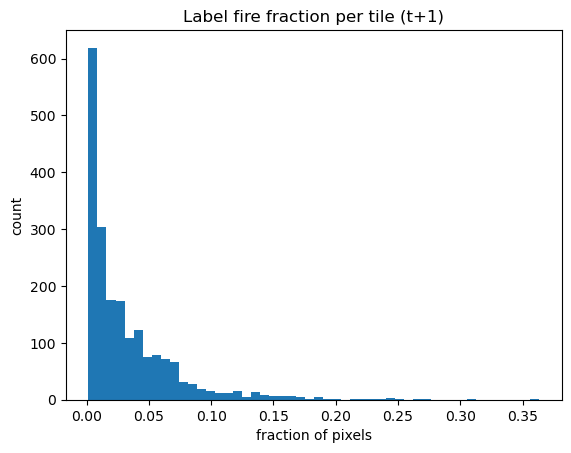

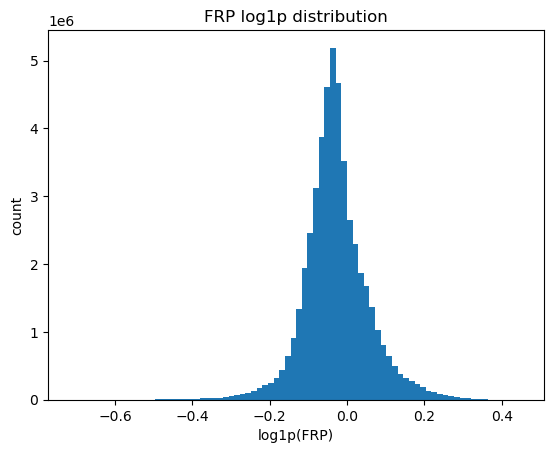

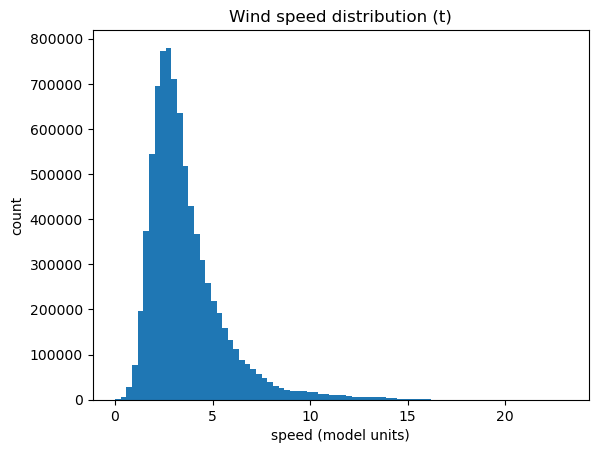

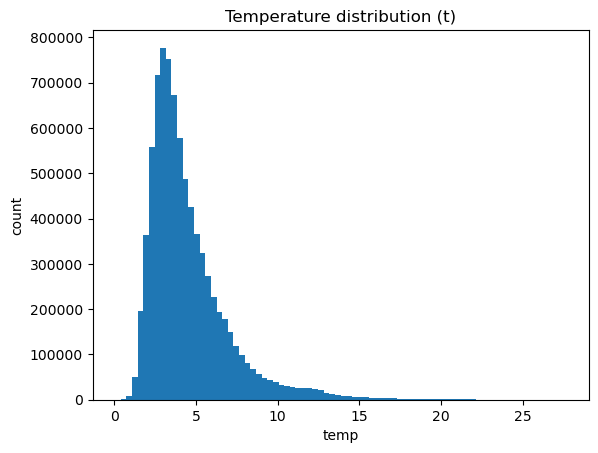

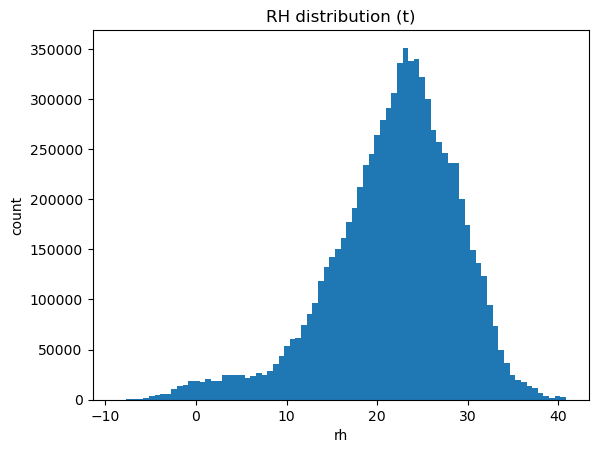

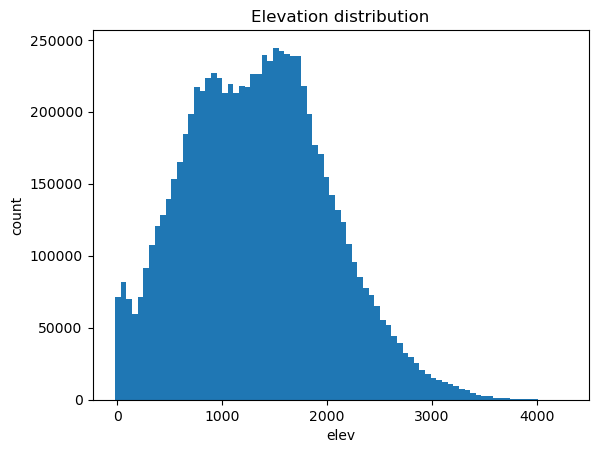

In [8]:
# Fire area balance
plt.figure(); plt.title("Label fire fraction per tile (t+1)")
plt.hist(df_lab["y_fire_frac"], bins=50); plt.xlabel("fraction of pixels"); plt.ylabel("count")

# FRP (log1p)
frp_vals = []
for p in subset:
    v = np.load(p)["x_dyn"][:,1]  # FRP channel
    frp_vals.append(np.log1p(v).ravel())
frp_vals = np.concatenate(frp_vals)
plt.figure(); plt.title("FRP log1p distribution")
plt.hist(frp_vals, bins=80); plt.xlabel("log1p(FRP)"); plt.ylabel("count")

# Wind speed from u,v (last timestep)
spd_vals = []
for p in subset:
    d = np.load(p)["x_dyn"]
    u, v = d[-1,2], d[-1,3]
    spd_vals.append(np.sqrt(u*u + v*v).ravel())
spd_vals = np.concatenate(spd_vals)
plt.figure(); plt.title("Wind speed distribution (t)")
plt.hist(spd_vals, bins=80); plt.xlabel("speed (model units)"); plt.ylabel("count")

# Temperature
temp_vals = []
for p in subset:
    temp_vals.append(np.load(p)["x_dyn"][-1,4].ravel())
temp_vals = np.concatenate(temp_vals)
plt.figure(); plt.title("Temperature distribution (t)")
plt.hist(temp_vals, bins=80); plt.xlabel("temp"); plt.ylabel("count")

# Relative humidity (or proxy)
rh_vals = []
for p in subset:
    rh_vals.append(np.load(p)["x_dyn"][-1,5].ravel())
rh_vals = np.concatenate(rh_vals)
plt.figure(); plt.title("RH distribution (t)")
plt.hist(rh_vals, bins=80); plt.xlabel("rh"); plt.ylabel("count")

# Elevation
elev_vals = []
for p in subset:
    elev_vals.append(np.load(p)["x_stat"][0].ravel())
elev_vals = np.concatenate(elev_vals)
plt.figure(); plt.title("Elevation distribution")
plt.hist(elev_vals, bins=80); plt.xlabel("elev"); plt.ylabel("count")

In [9]:
# NaNs / infs
def bad_counts(npz_paths, K=1000):
    n_nan = n_inf = 0
    for p in npz_paths[:K]:
        d = np.load(p)
        for k in ["x_dyn","x_stat","y"]:
            arr = d[k].astype("float32")
            n_nan += int(np.isnan(arr).sum())
            n_inf += int(np.isinf(arr).sum())
    return n_nan, n_inf

n_nan, n_inf = bad_counts(files, K=1000)
print("NaNs:", n_nan, " Infs:", n_inf)

# Are y and fire_t identical? (they shouldn't be)
def iou(a,b):
    a = (a>0.5).astype("float32"); b = (b>0.5).astype("float32")
    inter = (a*b).sum(); union = a.sum()+b.sum()-inter
    return float(inter/(union+1e-6))

ious = []
for p in subset[:200]:
    d = np.load(p)
    ious.append(iou(d["x_dyn"][-1,0], d["y"]))
print("Median IoU(fire_t, y):", np.median(ious))

NaNs: 0  Infs: 0
Median IoU(fire_t, y): 0.28571427465986465


In [10]:
from pathlib import Path
import numpy as np, random

# Find project root and tiles dir safely
ROOT = Path.cwd()
for p in [ROOT, *ROOT.parents]:
    if (p/"config.yaml").exists() and (p/"src").is_dir():
        ROOT = p; break

tiles_dir = ROOT / "data" / "mNDWS_500m"
files = sorted(tiles_dir.glob("*.npz"))
print("tiles_dir:", tiles_dir)
print("#tiles:", len(files))
assert files, "No .npz tiles found — double-check the path above."

# sample up to 500, but never more than we have
k = min(500, len(files))
random.seed(1)
subset = random.sample(files, k)

# Is FRP ever nonzero?
any_frp_nonzero = any(np.load(p)["x_dyn"][:,1].any() for p in subset)
nonzero_tile_count = sum(int(np.load(p)["x_dyn"][:,1].any()) for p in subset)
nonzero_pixel_count = sum(int((np.load(p)["x_dyn"][:,1] > 0).sum()) for p in subset)
total_pixel_count = sum(np.load(p)["x_dyn"][:,1].size for p in subset)

print(f"FRP nonzero in any sampled tile? {any_frp_nonzero}")
print(f"tiles with any FRP>0: {nonzero_tile_count}/{k}")
print(f"nonzero FRP pixels: {nonzero_pixel_count} of {total_pixel_count}")

tiles_dir: /Users/chrisjuarez/ignis_ml/data/mNDWS_500m
#tiles: 20097
FRP nonzero in any sampled tile? True
tiles with any FRP>0: 500/500
nonzero FRP pixels: 3362580 of 12288000
